<a href="https://colab.research.google.com/github/uday-andotra/WQU/blob/main/MScFE_610_FE_GWP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 619 Financial Econometrics Group Work Project #2

### Group Members: Udayveer Singh Andotra, Benjamin Nieves, Deep Mer

`April 2025`

Challenge 1: Feature Extraction

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import coint, adfuller
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [ ]:
# Challenge 1 & 2 Data: Banking Sector
# We need: Nifty 50 (Target), Nifty Bank (Predictor), HDFC Bank (Predictor), and other peers for PCA
bank_tickers = ['^NSEI', '^NSEBANK', 'HDFCBANK.NS', 'ICICIBANK.NS', 'AXISBANK.NS', 'KOTAKBANK.NS', 'INDUSINDBK.NS']

print("Downloading Data...")

In [ ]:
raw_data = yf.download(bank_tickers, start='2020-01-01', end='2024-01-01', auto_adjust=False)

# Robust Column Selection
if 'Adj Close' in raw_data.columns:
    data = raw_data['Adj Close']
elif 'Close' in raw_data.columns:
    print("Note: Using 'Close' column ('Adj Close' not found).")
    data = raw_data['Close']
else:
    # Fallback for complex MultiIndex
    try:
        data = raw_data.xs('Adj Close', level=0, axis=1)
    except:
        data = raw_data.xs('Close', level=0, axis=1)

[*********************100%***********************]  7 of 7 completed


In [ ]:
# Drop missing values to align dates
data = data.dropna()
print("Data Downloaded & Cleaned Successfully.")
print(f"Dataset Shape: {data.shape}")

Data Downloaded & Cleaned Successfully.
Dataset Shape: (991, 7)


In [ ]:
# Calculate Daily Returns
returns = data.pct_change().dropna()

<IPython.core.display.Javascript object>

PC1 explained variance: 66.80%
PC2 explained variance: 12.79%
Total variance explained by 2 components: 79.59%



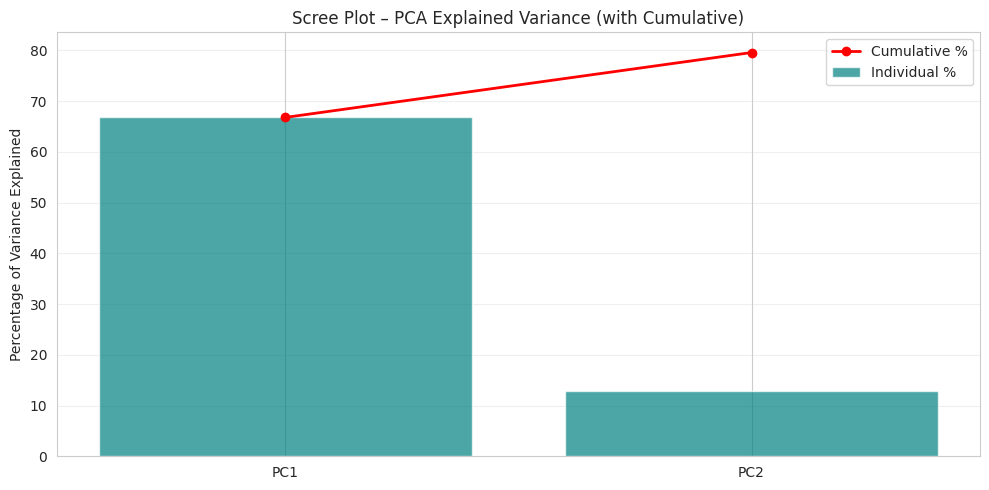

<Figure size 1000x600 with 0 Axes>

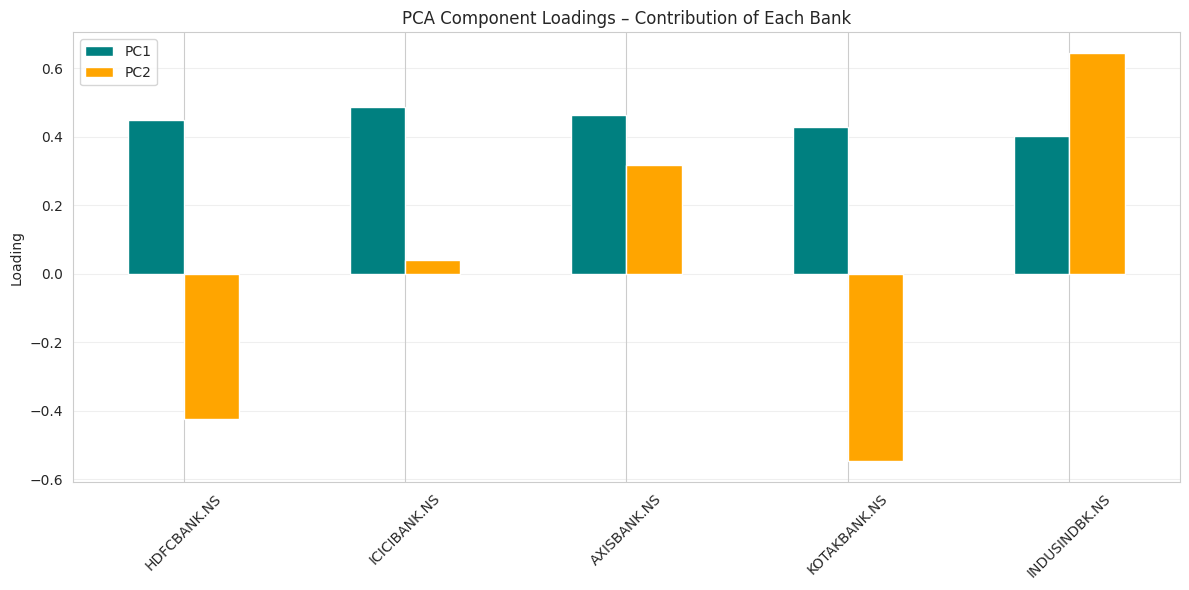

Correlation between PC1 and PC2 (should be exactly 0):
     PC1  PC2
PC1  1.0 -0.0
PC2 -0.0  1.0


In [ ]:
from google.colab import output
output.no_vertical_scroll()

pca_tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', 'AXISBANK.NS', 'KOTAKBANK.NS', 'INDUSINDBK.NS']
X_pca_raw = returns[pca_tickers]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_raw)

# Fit PCA (2 components)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
total_explained = np.sum(explained_var) * 100

print(f"PC1 explained variance: {explained_var[0]*100:.2f}%")
print(f"PC2 explained variance: {explained_var[1]*100:.2f}%")
print(f"Total variance explained by 2 components: {total_explained:.2f}%\n")

# 1. Enhanced Scree Plot with Cumulative Variance
cumulative_var = np.cumsum(explained_var) * 100
plt.figure(figsize=(10, 5))
plt.bar(['PC1', 'PC2'], explained_var*100, alpha=0.7, color='teal', label='Individual %')
plt.plot(['PC1', 'PC2'], cumulative_var, marker='o', color='red', linewidth=2, label='Cumulative %')
plt.title('Scree Plot – PCA Explained Variance (with Cumulative)')
plt.ylabel('Percentage of Variance Explained')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pca_scree_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. PCA Loadings Plot
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=pca_tickers)
plt.figure(figsize=(10, 6))
loadings.plot(kind='bar', color=['teal', 'orange'])
plt.title('PCA Component Loadings – Contribution of Each Bank')
plt.ylabel('Loading')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Orthogonality Check
pca_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
print("Correlation between PC1 and PC2 (should be exactly 0):")
print(pca_df.corr().round(4))

Challenge 2: Multicollinearity

In [ ]:
# STRATEGY:
# We predict Nifty 50 (^NSEI) using the Bank Nifty Index (^NSEBANK)
# AND its top 3 major components simultaneously.
# Since the Index IS the components, this creates massive redundancy.

# Define Predictors (X) and Target (Y)
X_multi = returns[['^NSEBANK', 'HDFCBANK.NS', 'ICICIBANK.NS', 'AXISBANK.NS']]
Y_target = returns['^NSEI']

VIF Results:
        Feature    VIF
0      ^NSEBANK  20.55
1   HDFCBANK.NS   5.13
2  ICICIBANK.NS   6.29
3   AXISBANK.NS   4.38

Regression Summary (key for Damage section):
                            OLS Regression Results                            
Dep. Variable:                  ^NSEI   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     1073.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:43:36   Log-Likelihood:                 3748.0
No. Observations:                 990   AIC:                            -7486.
Df Residuals:                     985   BIC:                            -7462.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err  

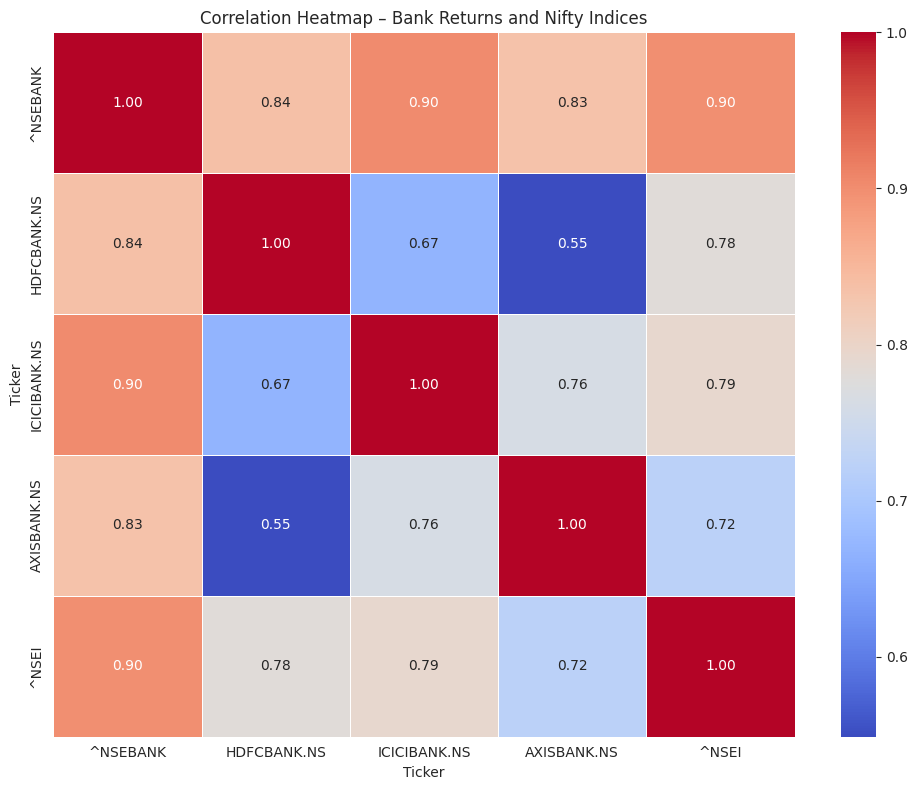

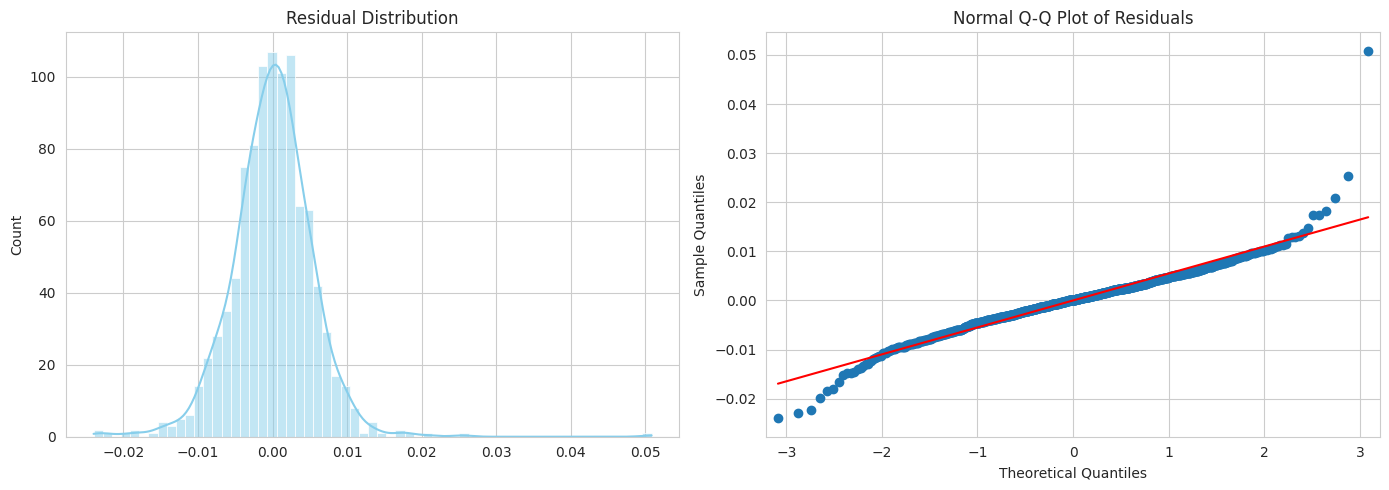

In [ ]:
from statsmodels.graphics.gofplots import qqplot
from google.colab import output
output.no_vertical_scroll()

X_const = sm.add_constant(X_multi)
model_vif = sm.OLS(Y_target, X_const).fit()

# VIF Table
vif_data = pd.DataFrame()
vif_data["Feature"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i) for i in range(len(X_multi.columns))]

print("VIF Results:")
print(vif_data.round(2))
print("\nRegression Summary (key for Damage section):")
print(model_vif.summary())

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(returns[['^NSEBANK', 'HDFCBANK.NS', 'ICICIBANK.NS', 'AXISBANK.NS', '^NSEI']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap – Bank Returns and Nifty Indices')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Residual Diagnostics
residuals = model_vif.resid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Residual Distribution')

qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

Challenge 3: Non-stationarity

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
import yfinance as yf
import pandas_datareader as pdr

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:
# Download S&P 500 price data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2023-12-31')['Close']
sp500.index = pd.to_datetime(sp500.index)

# Download Federal Funds Rate from FRED
fed_rate = pdr.get_data_fred('FEDFUNDS', start='2000-01-01', end='2023-12-31')
fed_rate.index = pd.to_datetime(fed_rate.index)

print("S&P 500 - Shape:", sp500.shape)
print(sp500.head())

print("\nFederal Funds Rate - Shape:", fed_rate.shape)
print(fed_rate.head())


/tmp/ipykernel_42603/3539754784.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start='2000-01-01', end='2023-12-31')['Close']
[*********************100%***********************]  1 of 1 completed

S&P 500 - Shape: (6037, 1)
Ticker            ^GSPC
Date                   
2000-01-03  1455.219971
2000-01-04  1399.420044
2000-01-05  1402.109985
2000-01-06  1403.449951
2000-01-07  1441.469971

Federal Funds Rate - Shape: (288, 1)
            FEDFUNDS
DATE                
2000-01-01      5.45
2000-02-01      5.73
2000-03-01      5.85
2000-04-01      6.02
2000-05-01      6.27


In [ ]:
# Resample S&P 500 to monthly frequency (last trading day of month)
sp500_monthly = sp500.resample('ME').last()

# Align both series
df = pd.DataFrame({
    'SP500': sp500_monthly.squeeze(),
    'FEDFUNDS': fed_rate['FEDFUNDS']
})

# Drop missing values
df = df.dropna()

print("Combined Dataset - Shape:", df.shape)
print(df.head())
print(df.tail())


Combined Dataset - Shape: (0, 2)
Empty DataFrame
Columns: [SP500, FEDFUNDS]
Index: []
Empty DataFrame
Columns: [SP500, FEDFUNDS]
Index: []


In [ ]:
# Resample S&P 500 to monthly frequency
sp500_monthly = sp500.resample('ME').last()

# Remove timezone info from both indexes
sp500_monthly.index = sp500_monthly.index.tz_localize(None)
fed_rate.index = fed_rate.index.tz_localize(None)

# Align both series
df = pd.DataFrame({
    'SP500': sp500_monthly.squeeze(),
    'FEDFUNDS': fed_rate['FEDFUNDS']
})

# Drop missing values
df = df.dropna()

print("Combined Dataset - Shape:", df.shape)
print(df.head())
print(df.tail())


Combined Dataset - Shape: (0, 2)
Empty DataFrame
Columns: [SP500, FEDFUNDS]
Index: []
Empty DataFrame
Columns: [SP500, FEDFUNDS]
Index: []


In [ ]:
# Check index types and sample values
print("SP500 monthly index type:", type(sp500_monthly.index))
print("SP500 monthly index sample:", sp500_monthly.index[:3])

print("\nFed Rate index type:", type(fed_rate.index))
print("Fed Rate index sample:", fed_rate.index[:3])


SP500 monthly index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
SP500 monthly index sample: DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31'], dtype='datetime64[ns]', name='Date', freq='ME')

Fed Rate index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Fed Rate index sample: DatetimeIndex(['2000-01-01', '2000-02-01', '2000-03-01'], dtype='datetime64[ns]', name='DATE', freq=None)


In [ ]:
# Normalize Fed Rate index to end of month to match SP500
fed_rate.index = fed_rate.index + pd.offsets.MonthEnd(0)

# Build combined dataframe
df = pd.DataFrame({
    'SP500': sp500_monthly.squeeze(),
    'FEDFUNDS': fed_rate['FEDFUNDS']
})

df = df.dropna()

print("Combined Dataset - Shape:", df.shape)
print(df.head())
print(df.tail())



Combined Dataset - Shape: (288, 2)
                  SP500  FEDFUNDS
2000-01-31  1394.459961      5.45
2000-02-29  1366.420044      5.73
2000-03-31  1498.579956      5.85
2000-04-30  1452.430054      6.02
2000-05-31  1420.599976      6.27
                  SP500  FEDFUNDS
2023-08-31  4507.660156      5.33
2023-09-30  4288.049805      5.33
2023-10-31  4193.799805      5.33
2023-11-30  4567.799805      5.33
2023-12-31  4769.830078      5.33


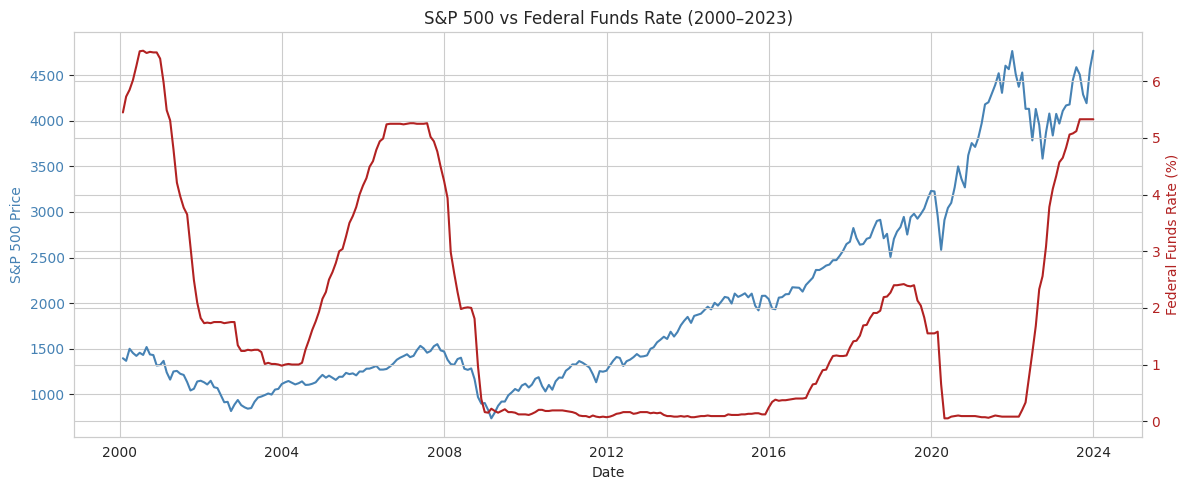

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot S&P 500
ax1.set_xlabel('Date')
ax1.set_ylabel('S&P 500 Price', color='steelblue')
ax1.plot(df.index, df['SP500'], color='steelblue', label='S&P 500')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Plot Fed Funds Rate on secondary axis
ax2 = ax1.twinx()
ax2.set_ylabel('Federal Funds Rate (%)', color='firebrick')
ax2.plot(df.index, df['FEDFUNDS'], color='firebrick', label='Fed Funds Rate')
ax2.tick_params(axis='y', labelcolor='firebrick')

plt.title('S&P 500 vs Federal Funds Rate (2000–2023)')
fig.tight_layout()
plt.savefig('sp500_vs_treasury.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Augmented Dickey-Fuller Test
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Test - {name}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] > 0.05:
        print(f'  Result: NON-STATIONARY (fail to reject H0)\n')
    else:
        print(f'  Result: STATIONARY (reject H0)\n')

adf_test(df['SP500'], 'S&P 500')
adf_test(df['FEDFUNDS'], 'Federal Funds Rate')


ADF Test - S&P 500
  ADF Statistic : 1.7777
  p-value       : 0.9983
  Critical Values:
    1%: -3.4545
    5%: -2.8722
    10%: -2.5724
  Result: NON-STATIONARY (fail to reject H0)

ADF Test - Federal Funds Rate
  ADF Statistic : -4.0592
  p-value       : 0.0011
  Critical Values:
    1%: -3.4540
    5%: -2.8720
    10%: -2.5723
  Result: STATIONARY (reject H0)



In [ ]:
# Replace Fed Funds Rate with 10-Year Treasury Rate (also non-stationary)
treasury = pdr.get_data_fred('GS10', start='2000-01-01', end='2023-12-31')
treasury.index = treasury.index + pd.offsets.MonthEnd(0)

# Rebuild combined dataframe
df = pd.DataFrame({
    'SP500': sp500_monthly.squeeze(),
    'GS10': treasury['GS10']
})
df = df.dropna()

print("Combined Dataset - Shape:", df.shape)
print(df.head())

# Run ADF on both
adf_test(df['SP500'], 'S&P 500')
adf_test(df['GS10'], '10-Year Treasury Rate')


Combined Dataset - Shape: (288, 2)
                  SP500  GS10
2000-01-31  1394.459961  6.66
2000-02-29  1366.420044  6.52
2000-03-31  1498.579956  6.26
2000-04-30  1452.430054  5.99
2000-05-31  1420.599976  6.44
ADF Test - S&P 500
  ADF Statistic : 1.7777
  p-value       : 0.9983
  Critical Values:
    1%: -3.4545
    5%: -2.8722
    10%: -2.5724
  Result: NON-STATIONARY (fail to reject H0)

ADF Test - 10-Year Treasury Rate
  ADF Statistic : -2.4295
  p-value       : 0.1336
  Critical Values:
    1%: -3.4535
    5%: -2.8717
    10%: -2.5722
  Result: NON-STATIONARY (fail to reject H0)



In [ ]:
# Spurious Regression - OLS between two non-stationary series
X = sm.add_constant(df['GS10'])
y = df['SP500']

spurious_model = sm.OLS(y, X).fit()
print(spurious_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  SP500   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     74.80
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           3.81e-16
Time:                        22:56:43   Log-Likelihood:                -2382.8
No. Observations:                 288   AIC:                             4770.
Df Residuals:                     286   BIC:                             4777.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3176.4966    149.569     21.238      0.0

In [ ]:
# Engle-Granger Cointegration Test
score, pvalue, _ = coint(df['SP500'], df['GS10'])

print('Engle-Granger Cointegration Test')
print(f'  Test Statistic : {score:.4f}')
print(f'  p-value        : {pvalue:.4f}')

if pvalue < 0.05:
    print('  Result: Series ARE cointegrated (long-run equilibrium exists)')
else:
    print('  Result: Series are NOT cointegrated')


Engle-Granger Cointegration Test
  Test Statistic : 0.9794
  p-value        : 1.0000
  Result: Series are NOT cointegrated


Challenge 4: Regime Change

<IPython.core.display.Javascript object>


Column structure:
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Adj Close shape: (1339, 1)
Ticker            AAPL
Date                  
2025-04-28  209.228104
2025-04-29  210.293457
2025-04-30  211.577850

Log returns shape: (1338, 1)


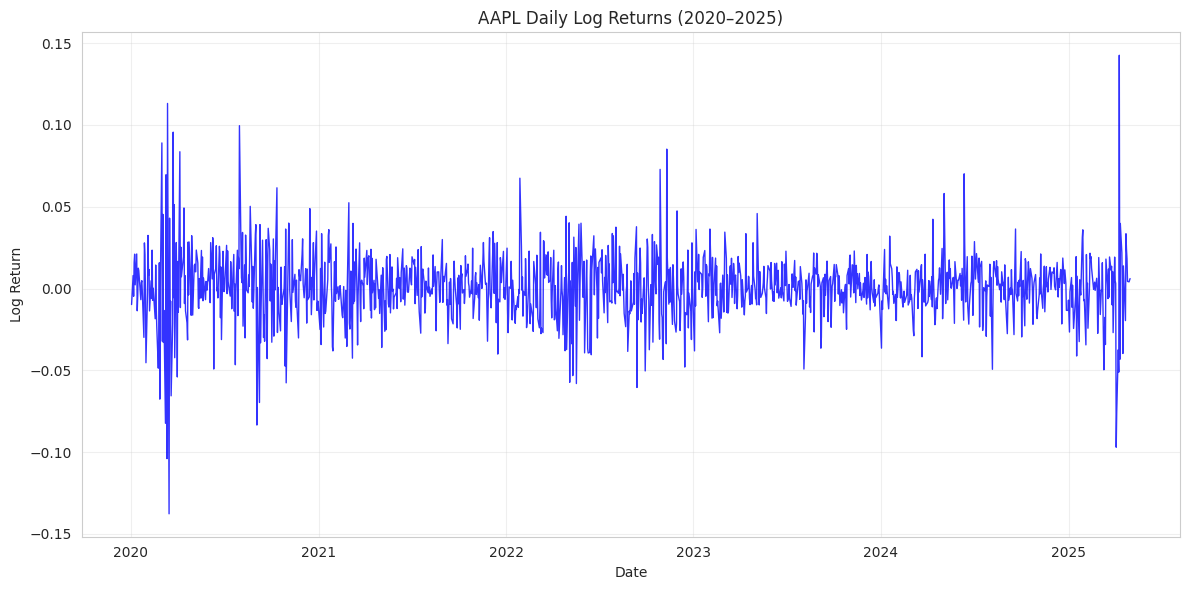


Fitting Markov Switching model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



=== MARKOV SWITCHING REGRESSION RESULTS ===
                        Markov Switching Model Results                        
Dep. Variable:                   AAPL   No. Observations:                 1338
Model:               MarkovRegression   Log Likelihood                3465.320
Date:                Mon, 20 Apr 2026   AIC                          -6918.640
Time:                        23:38:48   BIC                          -6887.446
Sample:                             0   HQIC                         -6906.952
                               - 1338                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0016      0.002     -0.646      0.518      -0.007       0.003
sigma2 

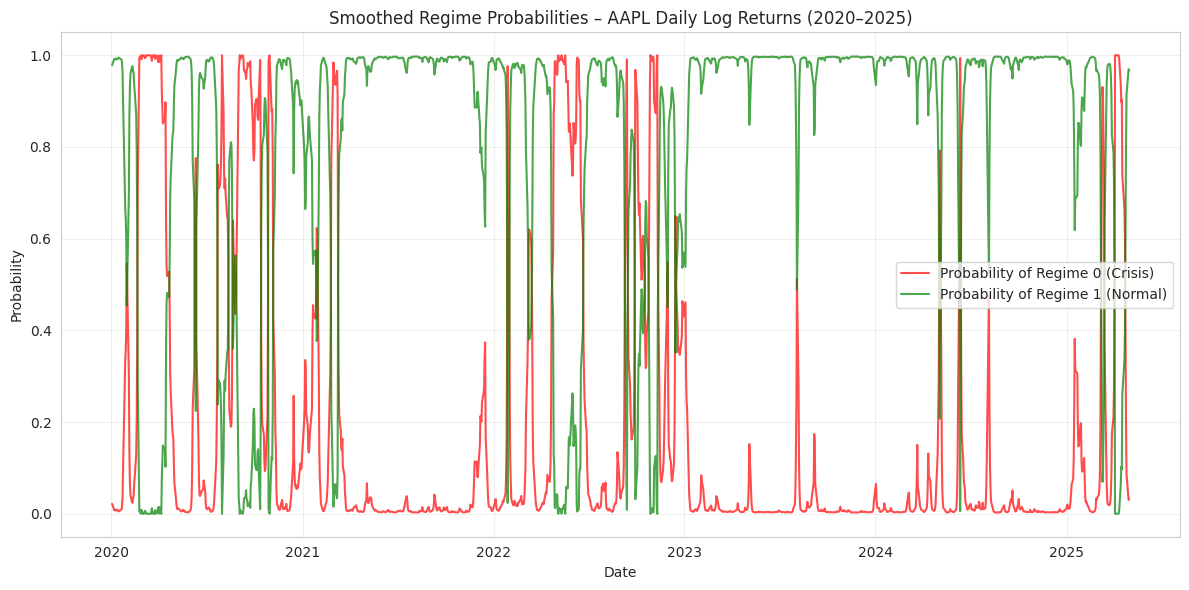


=== INTERPRETATION ===
Regime 0 mean: -0.00161
Regime 1 mean: 0.00136
Regime 0 sigma: 0.03696
Regime 1 sigma: 0.01427
Transition p(0→0): 0.8925
Transition p(1→0): 0.0247
Transition p(1→1): 0.9753


In [ ]:
from google.colab import output
output.no_vertical_scroll()

# 1. Install yfinance
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# 2. Download AAPL data (safe structure)
print("Downloading AAPL data...")
full_data = yf.download(
    'AAPL',
    start='2020-01-01',
    end='2025-05-01',
    progress=False,
    auto_adjust=False
)

print("\nColumn structure:")
print(full_data.columns)

# 3. Extract Adj Close prices
prices = full_data['Adj Close']
print(f"\nAdj Close shape: {prices.shape}")
print(prices.tail(3))

# 4. Compute daily log returns and plot
log_returns = np.log(prices).diff().dropna()
print(f"\nLog returns shape: {log_returns.shape}")

plt.figure(figsize=(12, 6))
plt.plot(log_returns.index, log_returns, color='blue', linewidth=1, alpha=0.8)
plt.title('AAPL Daily Log Returns (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_log_returns.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Fit 2-regime Markov Switching model (switching mean + variance)
print("\nFitting Markov Switching model...")
model = MarkovRegression(log_returns, k_regimes=2, trend='c', switching_variance=True)
res = model.fit(search_reps=10, maxiter=1000, disp=False)

# 6. Print full results
print("\n=== MARKOV SWITCHING REGRESSION RESULTS ===")
print(res.summary())

# 7. Regime probabilities plot
probs = res.smoothed_marginal_probabilities
plt.figure(figsize=(12, 6))
plt.plot(log_returns.index, probs[0], label='Probability of Regime 0 (Crisis)', color='red', alpha=0.7)
plt.plot(log_returns.index, probs[1], label='Probability of Regime 1 (Normal)', color='green', alpha=0.7)
plt.title('Smoothed Regime Probabilities – AAPL Daily Log Returns (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regime_probabilities.png', dpi=300, bbox_inches='tight')  # ← Saved for LaTeX

plt.show()

# 8. INTERPRETATION
print("\n=== INTERPRETATION ===")
print(f"Regime 0 mean: {res.params['const[0]']:.5f}")
print(f"Regime 1 mean: {res.params['const[1]']:.5f}")
print(f"Regime 0 sigma: {res.params['sigma2[0]']**0.5:.5f}")
print(f"Regime 1 sigma: {res.params['sigma2[1]']**0.5:.5f}")
print(f"Transition p(0→0): {res.params['p[0->0]']:.4f}")
print(f"Transition p(1→0): {res.params['p[1->0]']:.4f}")
print(f"Transition p(1→1): {1 - res.params['p[1->0]']:.4f}")   # derived